# BƯỚC 6 & 7: XAI (SHAP) + STREAMLIT WEB APP

- **Bước 6:** Dùng SHAP giải thích model XGBoost → xuất Top 3 lý do từ chối bằng tiếng Việt
- **Bước 7:** Chạy Streamlit Web App để demo thực tế

---
## BƯỚC 6 – Giải Thích AI (XAI with SHAP)

In [10]:
import pandas as pd, numpy as np, joblib, shap, warnings, urllib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
warnings.filterwarnings('ignore')
shap.initjs()

# Tải model và preprocessor
xgb_model    = joblib.load('xgb_model.pkl')
preprocessor = joblib.load('preprocessor.pkl')
print('✅ Đã tải model và preprocessor')

✅ Đã tải model và preprocessor


In [11]:
# Kết nối SQL Server, đọc bảng Gold
conn = ('DRIVER={ODBC Driver 17 for SQL Server};'
        'SERVER=localhost,1433;DATABASE=fintech;UID=sa;PWD=123456;')
engine  = create_engine(f'mssql+pyodbc:///?odbc_connect={urllib.parse.quote_plus(conn)}')
df_test = pd.read_sql('SELECT * FROM gold_credit_risk_test', engine)

X_test = df_test.drop('loan_status', axis=1)
y_pred = xgb_model.predict(X_test)
print(f'Test set: {len(X_test)} mẫu | Từ chối: {sum(y_pred==1)} | Phê duyệt: {sum(y_pred==0)}')

Test set: 6515 mẫu | Từ chối: 1214 | Phê duyệt: 5301


In [12]:
# Tên features & map tiếng Việt
num_feats = ['person_age','person_income','person_emp_length',
             'loan_amnt','loan_int_rate','loan_percent_income','cb_person_default_on_file']
ohe_feats = list(preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(['person_home_ownership','loan_intent']))
all_feats = num_feats + ohe_feats

feat_vi = {
    'person_age':'Tuổi', 'person_income':'Thu nhập', 'person_emp_length':'Thâm niên (năm)',
    'loan_amnt':'Số tiền vay', 'loan_int_rate':'Lãi suất', 'loan_percent_income':'Tỷ lệ vay/TN',
    'cb_person_default_on_file':'Lịch sử vỡ nợ',
    'person_home_ownership_MORTGAGE':'Nhà: Thế chấp','person_home_ownership_OWN':'Nhà: Sở hữu',
    'person_home_ownership_RENT':'Nhà: Thuê','person_home_ownership_OTHER':'Nhà: Khác',
    'loan_intent_DEBTCONSOLIDATION':'Vay: Gộp nợ','loan_intent_EDUCATION':'Vay: Học tập',
    'loan_intent_HOMEIMPROVEMENT':'Vay: Sửa nhà','loan_intent_MEDICAL':'Vay: Y tế',
    'loan_intent_PERSONAL':'Vay: Cá nhân','loan_intent_VENTURE':'Vay: Kinh doanh',
}

# Tính SHAP values
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP shape: {shap_values.shape}')

SHAP shape: (6515, 17)


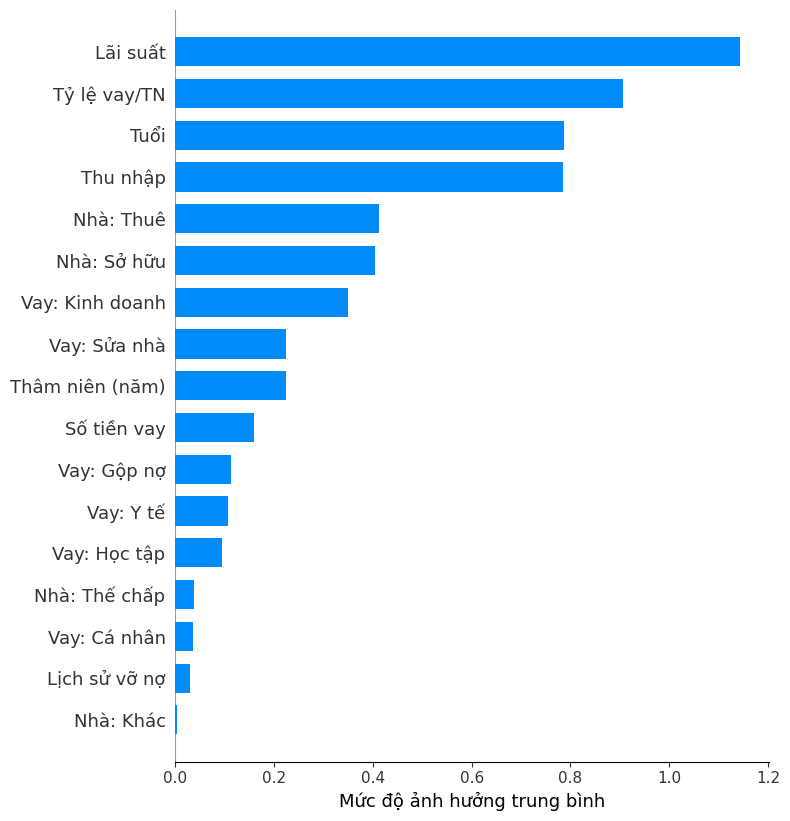

In [ ]:
# Summary plot – tổng thể
shap.summary_plot(shap_values, X_test,
                  feature_names=[feat_vi.get(f,f) for f in all_feats],
                  plot_type='bar' ,
                  show=False)
plt.xlabel('Mức độ ảnh hưởng trung bình');

In [14]:
# Hàm xuất Top 3 lý do từ chối
y_prob = xgb_model.predict_proba(X_test)[:, 1] 
def ly_do_tu_choi(idx):
    sv    = shap_values[idx]
    order = np.argsort(np.abs(sv))[::-1]
    print(f'\n=== HỒ SƠ #{idx} | Xác suất vỡ nợ: {y_prob[idx]:.1%} | ⛔ TỪ CHỐI ===')
    count = 0
    for i in order:
        if sv[i] > 0 and count < 3:
            count += 1
            ten = feat_vi.get(all_feats[i], all_feats[i])
            print(f'  Lý do {count}: {ten} = {X_test.iloc[idx, i]:.2f}  (SHAP: +{sv[i]:.4f})')
    if count == 0:
        print('  (Không tìm được lý do SHAP dương riêng lẻ)')

# Demo 3 hồ sơ bị từ chối đầu tiên
rejected = np.where(y_pred == 1)[0]
for idx in rejected[:3]:
    ly_do_tu_choi(idx)


=== HỒ SƠ #3 | Xác suất vỡ nợ: 99.4% | ⛔ TỪ CHỐI ===
  Lý do 1: Tỷ lệ vay/TN = 1.78  (SHAP: +3.8667)
  Lý do 2: Nhà: Thuê = 1.00  (SHAP: +1.0771)
  Lý do 3: Số tiền vay = 2.43  (SHAP: +0.5310)

=== HỒ SƠ #11 | Xác suất vỡ nợ: 74.1% | ⛔ TỪ CHỐI ===
  Lý do 1: Lãi suất = 1.27  (SHAP: +1.8388)
  Lý do 2: Vay: Gộp nợ = 1.00  (SHAP: +0.5136)
  Lý do 3: Thu nhập = -0.57  (SHAP: +0.2145)

=== HỒ SƠ #30 | Xác suất vỡ nợ: 92.2% | ⛔ TỪ CHỐI ===
  Lý do 1: Lãi suất = 1.48  (SHAP: +2.3618)
  Lý do 2: Vay: Y tế = 1.00  (SHAP: +0.8844)
  Lý do 3: Thu nhập = -0.73  (SHAP: +0.4718)


In [20]:
# Hàm xuất Top 3 lý do phê duyệt
def ly_do_phe_duyet(idx):
    sv    = shap_values[idx]
    order = np.argsort(np.abs(sv))[::-1]
    xac_suat_an_toan = 1 - y_prob[idx]
    print(f'\n=== HỒ SƠ #{idx} | Xác suất an toàn: {xac_suat_an_toan:.1%} | ✅ PHÊ DUYỆT ===')
    count = 0
    for i in order:
        if sv[i] < 0 and count < 3:
            count += 1
            ten = feat_vi.get(all_feats[i], all_feats[i])
            print(f'  Điểm cộng {count}: {ten} = {X_test.iloc[idx, i]:.2f}  (SHAP: {sv[i]:.4f})')
            
    if count == 0:
        print('  (Không tìm được lý do SHAP âm riêng lẻ)')

# Demo 3 hồ sơ ĐƯỢC PHÊ DUYỆT đầu tiên (y_pred == 0)
approved = np.where(y_pred == 0)[0]
for idx in approved[:3]:
    ly_do_phe_duyet(idx)


=== HỒ SƠ #0 | Xác suất an toàn: 94.8% | ✅ PHÊ DUYỆT ===
  Điểm cộng 1: Lãi suất = -1.28  (SHAP: -1.5982)
  Điểm cộng 2: Tuổi = -0.28  (SHAP: -0.7972)
  Điểm cộng 3: Tỷ lệ vay/TN = 0.65  (SHAP: -0.6656)

=== HỒ SƠ #1 | Xác suất an toàn: 71.6% | ✅ PHÊ DUYỆT ===
  Điểm cộng 1: Tuổi = -0.44  (SHAP: -1.4522)
  Điểm cộng 2: Nhà: Thuê = 0.00  (SHAP: -0.6484)
  Điểm cộng 3: Lãi suất = 0.37  (SHAP: -0.4656)

=== HỒ SƠ #2 | Xác suất an toàn: 87.1% | ✅ PHÊ DUYỆT ===
  Điểm cộng 1: Lãi suất = -1.79  (SHAP: -2.0534)
  Điểm cộng 2: Tuổi = 0.04  (SHAP: -0.6854)
  Điểm cộng 3: Tỷ lệ vay/TN = -0.00  (SHAP: -0.6615)


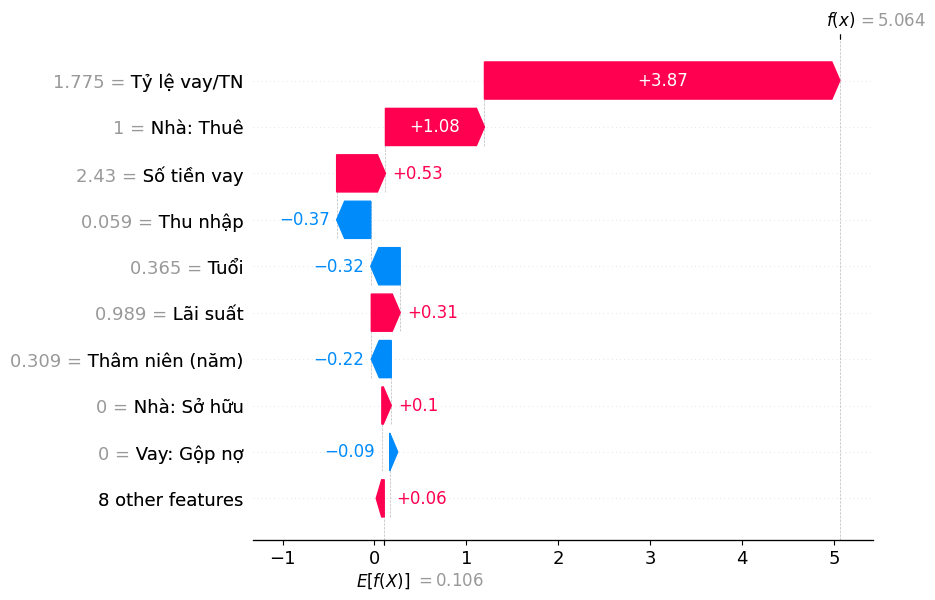

In [19]:
# Waterfall plot – giải thích chi tiết 1 hồ sơ từ chối
idx_demo = rejected[0]
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[idx_demo],
        base_values = explainer.expected_value,
        data        = X_test.iloc[idx_demo].values,
        feature_names=[feat_vi.get(f,f) for f in all_feats]
    )
)

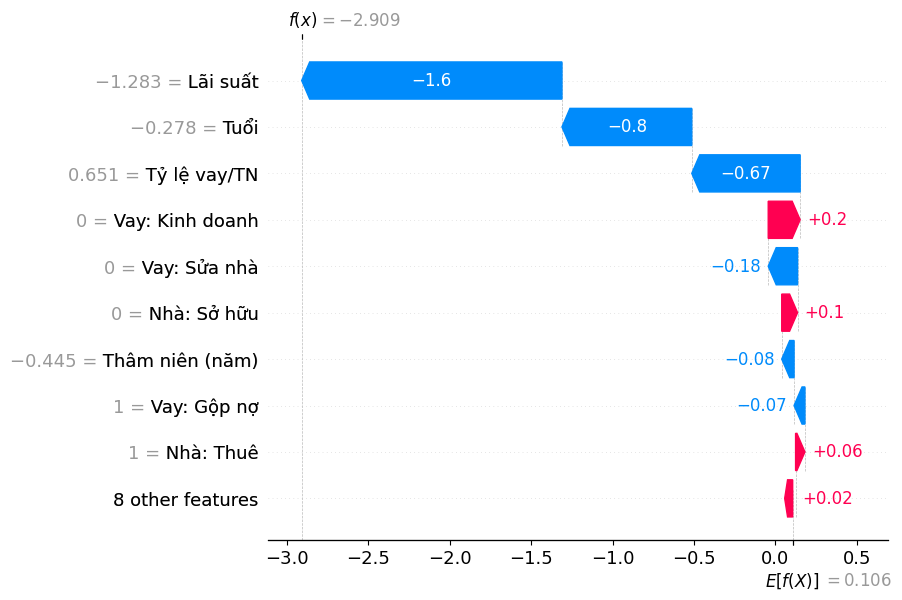

In [ ]:
# Waterfall plot – giải thích chi tiết 1 hồ sơ PHÊ DUYỆT
idx_demo_approve = approved[0]
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[idx_demo_approve],
        base_values = explainer.expected_value,
        data        = X_test.iloc[idx_demo_approve].values,
        feature_names=[feat_vi.get(f,f) for f in all_feats]
    )
)

---
## BƯỚC 7 – Streamlit Web App

Mở **Terminal** tại thư mục `Giai thich va demo`, chạy:
```
streamlit run app.py
```
Trình duyệt tự mở tại: **http://localhost:8501**

Hoặc chạy cell dưới để khởi động ngay từ notebook:

In [16]:
import subprocess, sys
subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py',
                  '--server.port', '8501', '--server.headless', 'true'])
print('✅ Streamlit chạy tại http://localhost:8501')

✅ Streamlit chạy tại http://localhost:8501
